<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object Detection**

Metode yang digunakan
1. Template Matching
2. Edge Detection
3. Comer Detection
4. Grid Delection
5. Contour Detection

## **D1. Basic Object Detection Practicum**

1.	Open https://colab.research.google.com/. Once you've confirmed that Google Colab is connected to your GitHub, create a new notebook and name it "Week11.ipynb." Then, import several libraries and access the folders in your Drive as follows.

In [1]:
# import library
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# drive access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2.	Implement 6 template matching methods in OpenCV using the images cats_and_bunnies.jpg and cat2_templatejpg.jpg as templates.

**Template Matching**

Menggunakan library openCV:

cv.matchTemplate(), dengan parameter:
- **image**: citra input
- **templ**: template yang dicari, ukurannya tidak boleh lebih besar dari citra input
- **method**: metode dari template matching

Jenis metode template matching di OpenCV:
1. TM_SODIFF
2. TM.SQDIFF_NORMED
3. TM.CCORR
4. TM_CCORR_NORMED
5. TM_COOEFF
6. TM_CCOEFF_NORMED

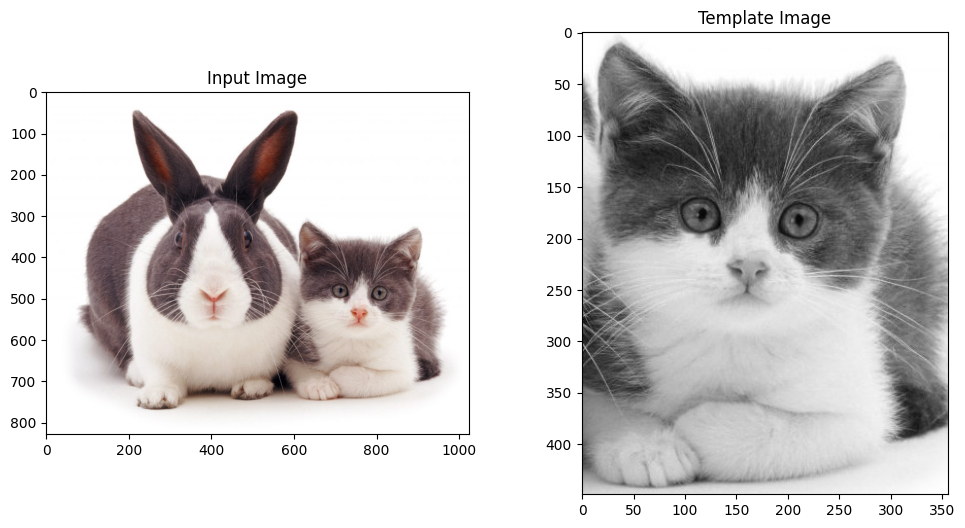

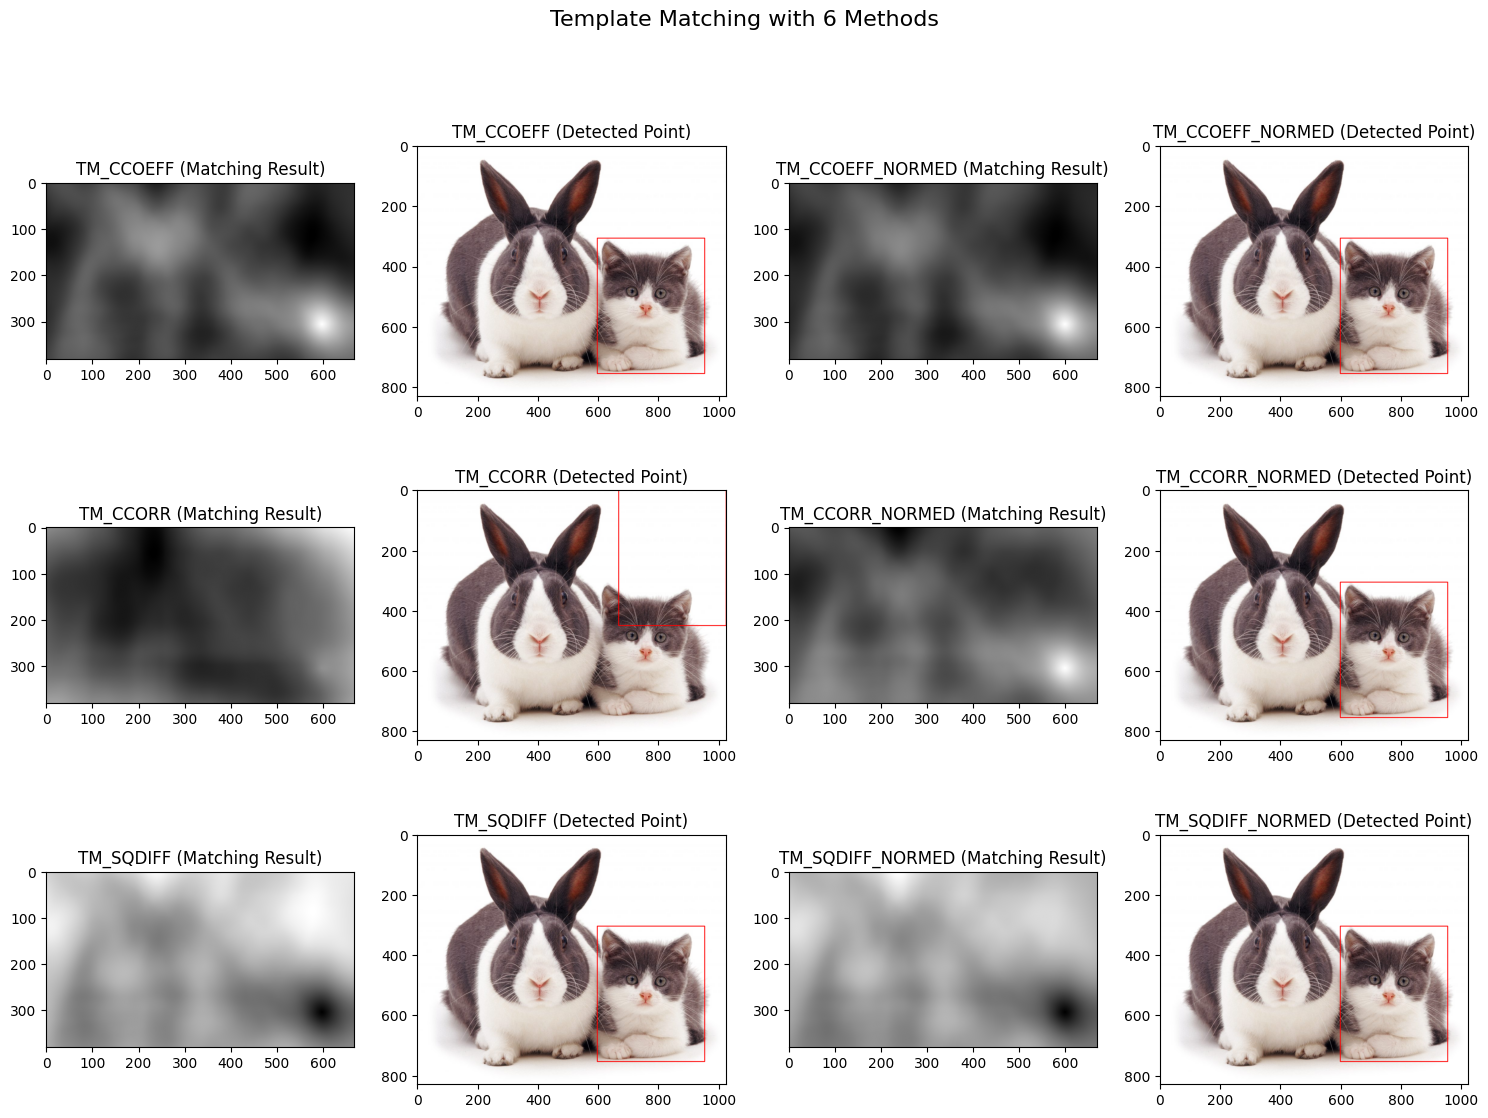

In [24]:
img_path = '/content/drive/MyDrive/PCVK/Images/Object Detection/cats_and_bunnies.jpg'
template_path = '/content/drive/MyDrive/PCVK/Images/Object Detection/cat2_templatejpg.jpg'

# Read the image and the template
img_rgb = cv.imread(img_path)
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template = cv.imread(template_path, 0)
w, h = template.shape[::-1]

# List of available template matching methods in OpenCV
methods = [
    'cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
    'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED'
]

# Display Input Image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_rgb, cv.COLOR_BGR2RGB))
plt.title('Input Image')

# Display Template Image
plt.subplot(1, 2, 2)
plt.imshow(template, cmap='gray')
plt.title('Template Image')

plt.show()

# --- DISPLAY MATCHING RESULTS ---
plt.figure(figsize=(15, 12))
for i, m in enumerate(methods):
    method = eval(m)

    # 1. Apply Template Matching
    res = cv.matchTemplate(img_gray, template, method)

    # 2. Find the best matching location
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # Choose location based on the method type
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc  # Min value = best match for SQDIFF
    else:
        top_left = max_loc  # Max value = best match for CCORR/CCOEFF

    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Create a copy of the image to draw the bounding box
    img_display = img_rgb.copy()
    cv.rectangle(img_display, top_left, bottom_right, (0, 0, 255), 2)

    # Display results (Matching Result & Detected Point)

    # Matching Result (Matrix R)
    plt.subplot(3, 4, 2*i + 1), plt.imshow(res, cmap='gray')  # Matrix R
    plt.title(m.replace('cv.', '') + ' (Matching Result)')

    # Detected Point (Bounding Box)
    plt.subplot(3, 4, 2*i + 2), plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))  # Image with bounding box
    plt.title(m.replace('cv.', '') + ' (Detected Point)')
plt.suptitle("Template Matching with 6 Methods", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


3.	Implement the template matching concept without using the OpenCV library for multiple objects, using the image bahrain.jpg as the input image and bahrain-template.jpg as the template image, resulting in the following output:

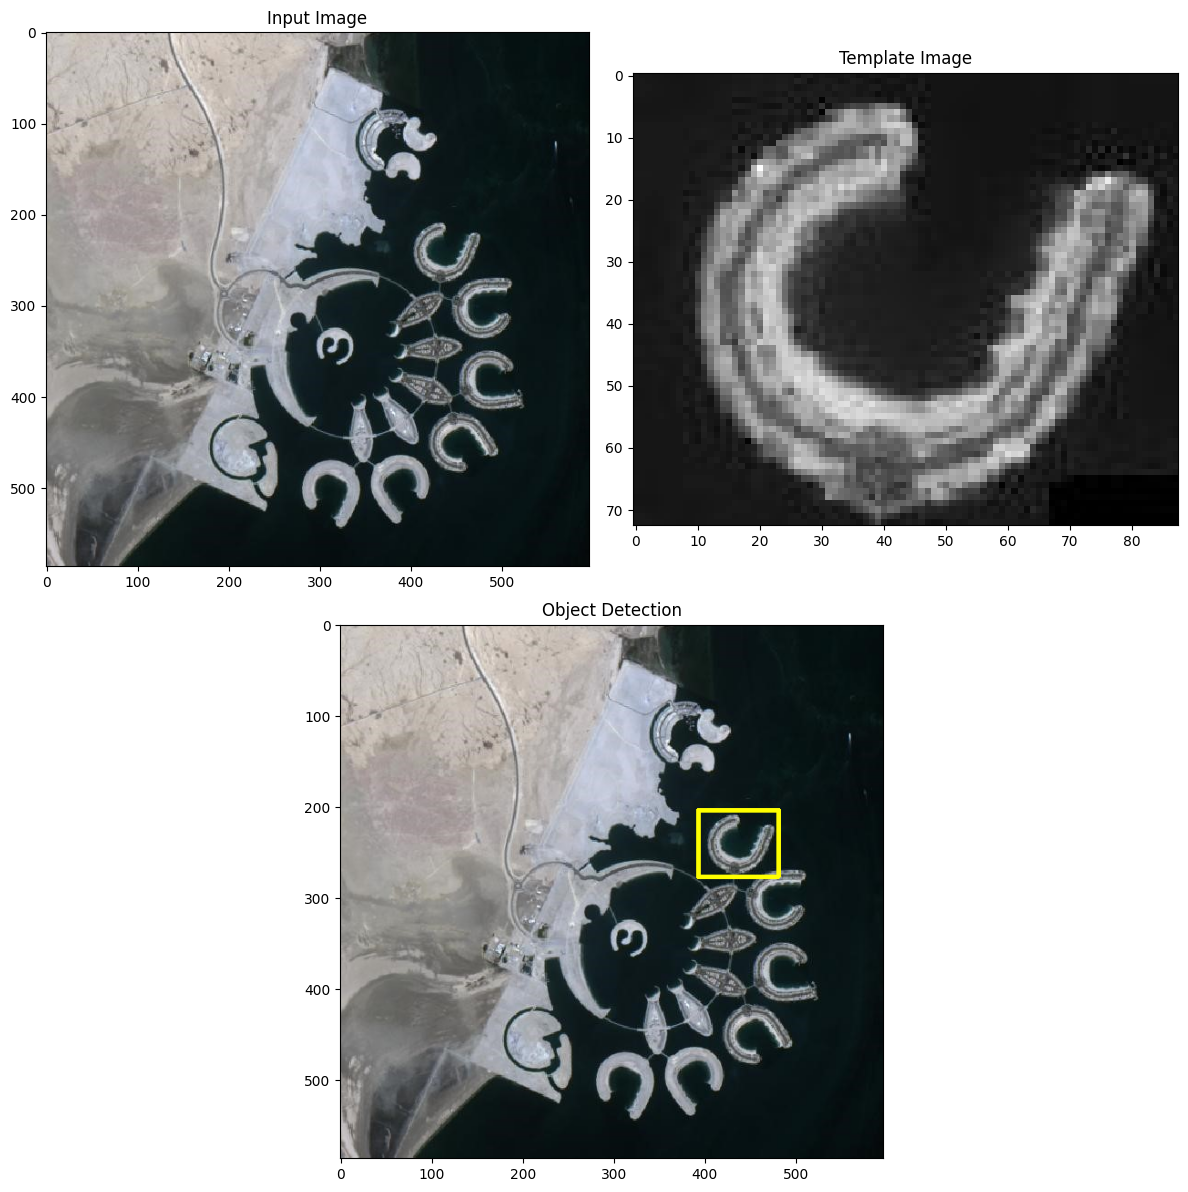

In [22]:
img_path_bahrain = '/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain.jpg'
template_path_bahrain = '/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain-template.jpg'

# Read the image and template (Grayscale)
img_bgr = cv.imread(img_path_bahrain)
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
template = cv.imread(template_path_bahrain, 0)
w, h = template.shape[::-1]

# Use the CCOEFF_NORMED matching method
res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

# Set threshold
# This threshold value might need adjustment (e.g., 0.75 - 0.85) for optimal results
threshold = 0.85
loc = np.where(res >= threshold)

# Create a copy of the image to draw bounding boxes
img_display = img_bgr.copy()

# Draw bounding boxes on every location above the threshold
# (Using np.where to get all matching coordinates)
for pt in zip(*loc[::-1]):  # zip(*loc[::-1]) converts to (x, y) coordinates
    # Box color: (B, G, R) = (0, 255, 255) is Yellow
    cv.rectangle(img_display, pt, (pt[0] + w, pt[1] + h), (0, 255, 255), 2)

# Display Result

plt.figure(figsize=(12, 12))

# Input Image
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
plt.title('Input Image')

# Template Image
plt.subplot(2, 2, 2)
plt.imshow(template, cmap='gray')
plt.title('Template Image')

# Detection Result
plt.subplot(2, 1, 2)
plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))
plt.title(f'Object Detection')

plt.tight_layout()
plt.show()

4.	Implement the Sobel Edge Detection, Canny Edge Detection, and Laplacian Edge Detection methods in OpenCV using the car-park.jpg image, resulting in the following output:

  a.	Sobel Edge Detection

  b.	Canny Edge Detection

  c.	Laplacian Edge Detection

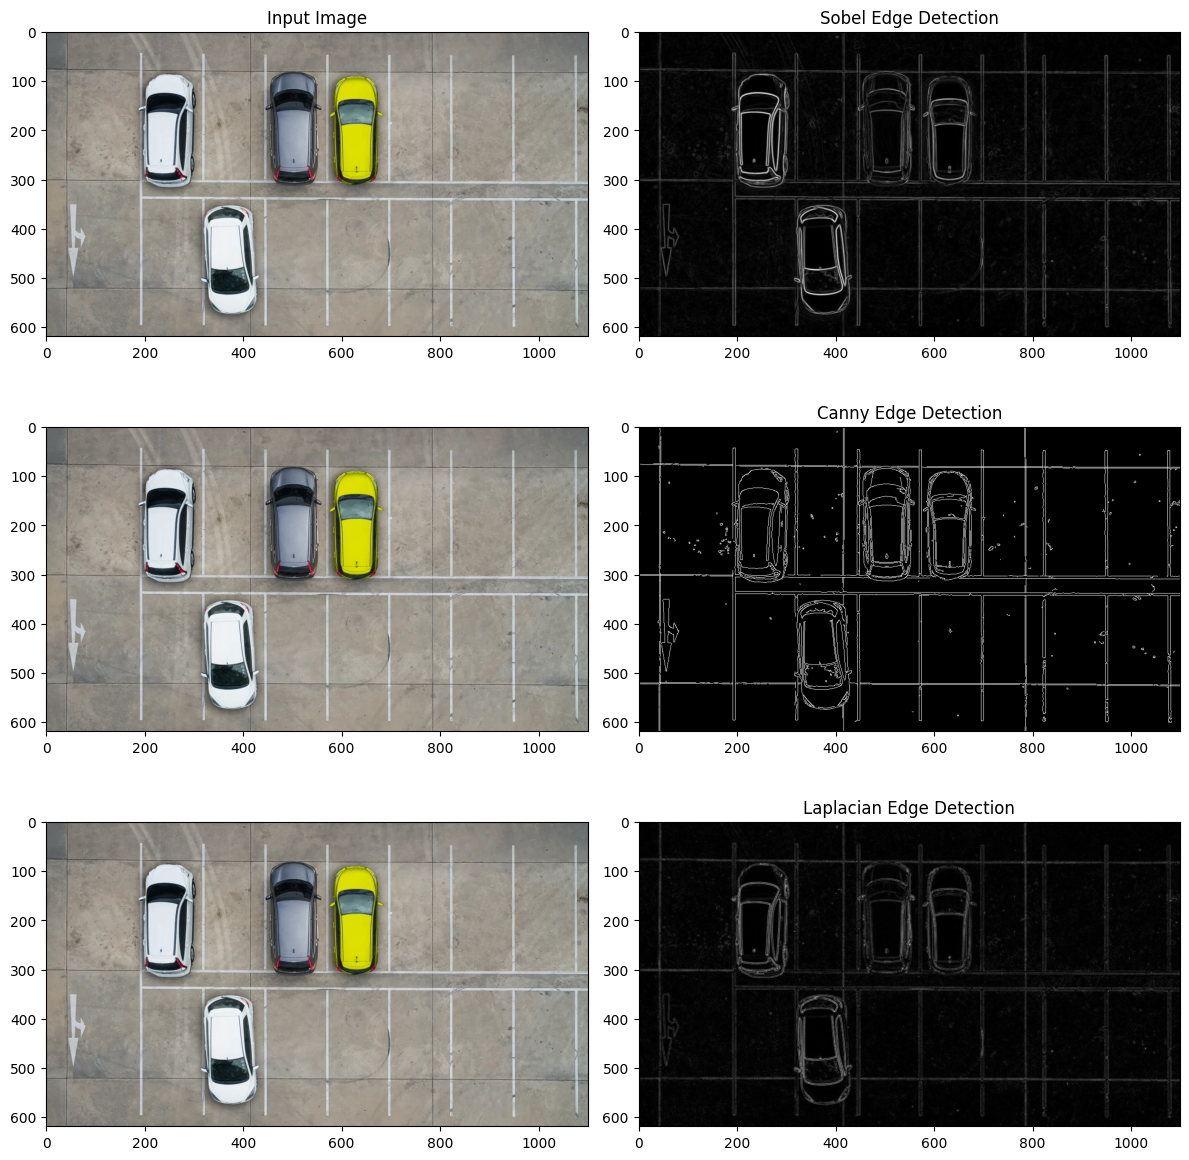

In [27]:
img_path_carpark = '/content/drive/MyDrive/PCVK/Images/Object Detection/car-park.jpg'

# Read the image
img_color = cv.imread(img_path_carpark)  # Read the color version for input display
img_carpark = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)  # Grayscale version for edge detection

# --- Sobel Edge Detection ---
sobelx = cv.Sobel(img_carpark, cv.CV_64F, 1, 0, ksize=5)  # dx=1, dy=0
sobely = cv.Sobel(img_carpark, cv.CV_64F, 0, 1, ksize=5)  # dx=0, dy=1
sobel_combined = cv.magnitude(sobelx, sobely)
sobel_output = cv.normalize(sobel_combined, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

# --- Canny Edge Detection ---
canny_output = cv.Canny(img_carpark, 100, 200)

# --- Laplacian Edge Detection ---
img_blur = cv.GaussianBlur(img_carpark, (3, 3), 0)
laplacian = cv.Laplacian(img_blur, cv.CV_64F)
laplacian_abs = cv.convertScaleAbs(laplacian)
laplacian_output = cv.normalize(laplacian_abs, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

# List of edge detection results for plotting
edge_results = [
    ('Sobel Edge Detection', sobel_output),
    ('Canny Edge Detection', canny_output),
    ('Laplacian Edge Detection', laplacian_output)
]

# Display Result
plt.figure(figsize=(12, 12))

for i, (title, output_img) in enumerate(edge_results):
    # Display Input Image
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
    # Only show 'Input Image' title in the first row to avoid redundancy
    if i == 0:
        plt.title('Input Image')

    # Display Edge Detection Result
    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(output_img, cmap='gray')
    plt.title(title)

plt.tight_layout()
plt.show()


5.	Implement the Harris Corner Detection and Shi-Tomasi Detection methods in OpenCV using the car-park.jpg image, resulting in the following output:

  a.  Harris Corner Detection

  b.  Shi-Tomasi Detection

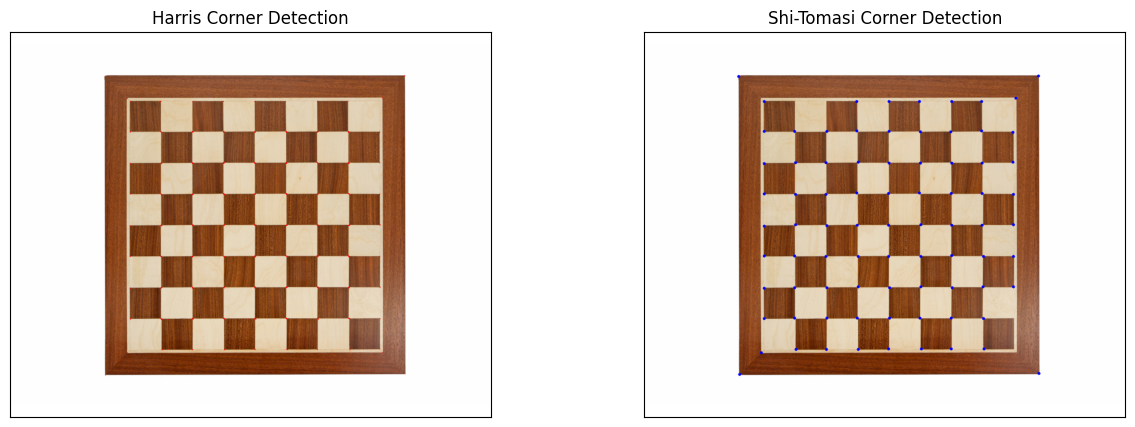

In [33]:
img_path_chess = '/content/drive/MyDrive/PCVK/Images/Object Detection/chess-board.jpg'

# Read the image (Color for output visualization, Grayscale for computation)
img_color = cv.imread(img_path_chess)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# --- Harris Corner Detection ---
# Convert to float32 (required for cornerHarris)
img_gray_float = np.float32(img_gray)

# Compute the Harris response (R)
dst = cv.cornerHarris(img_gray_float, blockSize=2, ksize=3, k=0.04)

# Multiply Harris response by 0.01 * dst.max() for thresholding
img_harris = img_color.copy()
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]  # Mark corners with blue pixels (BGR)

# --- Shi-Tomasi Corner Detection ---
corners = cv.goodFeaturesToTrack(img_gray, maxCorners=81, qualityLevel=0.05, minDistance=20)
corners = np.intp(corners)  # Corrected: Use np.intp instead of np.int0

img_shimas = img_color.copy()

# Draw circles on each detected corner
for i in corners:
    x, y = i.ravel()
    cv.circle(img_shimas, (x, y), 3, (255, 0, 0), -1)  # Blue circles (BGR)

# Display Results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img_harris, cv.COLOR_BGR2RGB))
plt.title('Harris Corner Detection'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(cv.cvtColor(img_shimas, cv.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Corner Detection'), plt.xticks([]), plt.yticks([])

plt.show()

6.	Implement the Hough Transform method in OpenCV using the sudoku.jpg image. The grid detection process steps are as described in the theoretical review, resulting in the following output:


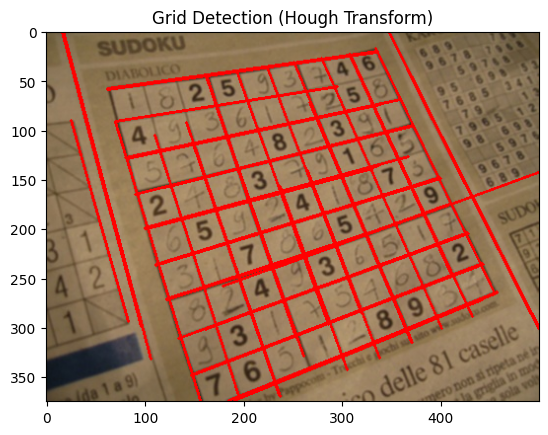

In [47]:
img_path_sudoku = '/content/drive/MyDrive/PCVK/Images/Object Detection/sudoku.jpg'

# Read the image
img_bgr = cv.imread(img_path_sudoku)

# Create copies for processing and drawing
img_draw = img_bgr.copy()
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

# --- Adaptive Thresholding ---
# Block size = 11, C = 5 works
img_contrast = cv.adaptiveThreshold(
    img_gray, 255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY_INV,
    11, 5
)

# --- Edge Detection and Morphological Operations ---
edges = cv.Canny(img_contrast, 50, 150, apertureSize=3)
kernel = np.ones((3, 3), np.uint8)
dilated = cv.dilate(edges, kernel, iterations=1)
eroded = cv.erode(dilated, kernel, iterations=1)

# --- Hough Transform for Line Detection ---
lines = cv.HoughLinesP(
    eroded, 1, np.pi / 180,
    threshold=220,        # Higher threshold for stricter line detection
    minLineLength=150,    # Only detect long lines (ignore small ones)
    maxLineGap=10
)

# --- Draw the Detected Lines ---
if lines is not None:
    line_color = (0, 0, 255)  # Red lines (BGR)
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(img_draw, (x1, y1), (x2, y2), line_color, 2)

# Display Result
plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
plt.title('Grid Detection (Hough Transform)')
plt.show()

7.	Implement the findContours() function in OpenCV for contour detection using the laptop.jpg image, resulting in the following output:

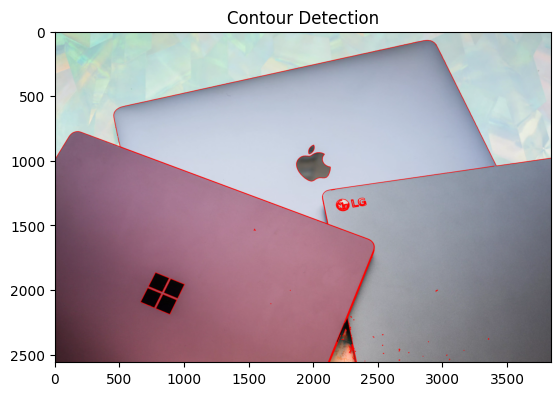

In [53]:
import os

img_path_laptop = '/content/drive/MyDrive/PCVK/Images/Object Detection/laptop.jpg'

# Read the image (in color)
img_bgr = cv.imread(img_path_laptop)

# --- Image Preparation ---
img_draw = img_bgr.copy()  # Copy for contour drawing
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)  # Convert to grayscale

# --- Convert to Binary Image ---
# Using Canny Edge Detection for cleaner edges
edges = cv.Canny(img_gray, 50, 150)

# --- Find Contours ---
# cv.findContours takes a binary image
# cv.RETR_TREE retrieves all contours and reconstructs hierarchy
# cv.CHAIN_APPROX_SIMPLE compresses contour points to save memory
contours, hierarchy = cv.findContours(edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# --- Draw Contours ---
# -1 means draw all detected contours
cv.drawContours(img_draw, contours, -1, (0, 0, 255), 3)

# Display Result
plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
plt.title('Contour Detection')
plt.show()

## **D2. Feature Matching and Face Detection Practicum**

1. Perform face detection on another image object available at (/images/facedet). Display it as in the following example.

Face Detection Result


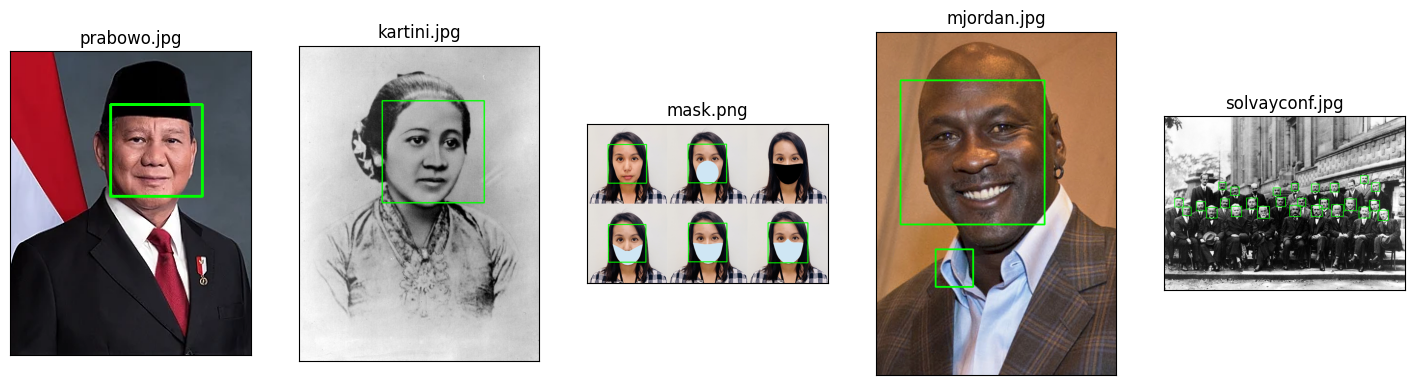

In [60]:
print(f'Face Detection Result')

# Base path for the 'haarcascades' folder
base_path_files = '/content/drive/MyDrive/PCVK/Images'
face_cascade_path = os.path.join(base_path_files, 'haarcascades/haarcascade_frontalface_default.xml')

# Load Haar Cascade classifier
face_cascade = cv.CascadeClassifier(face_cascade_path)

# List of images to test
images_to_test = [
    'facedet/prabowo.jpg',
    'facedet/kartini.jpg',
    'facedet/mask.png',
    'facedet/mjordan.jpg',
    'facedet/solvayconf.jpg'
]

results = []
image_names = []

# --- Process Each Image ---
for img_entry in images_to_test:
    # If path starts with '/', treat it as an absolute path
    if img_entry.startswith('/'):
        img_path = img_entry
        name = img_entry.split('/')[-1]
    else:
        img_path = os.path.join(base_path_files, img_entry)
        name = img_entry.split('/')[-1]

    img_color = cv.imread(img_path)

    if img_color is not None:
        # Convert to grayscale for detection
        img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

        # Detect faces using the Haar Cascade
        faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

        # Copy image for drawing
        img_draw = img_color.copy()

        # Draw green rectangles around detected faces
        for (x, y, w, h) in faces:
            cv.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Store the processed image and its name
        results.append(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
        image_names.append(name)
    else:
        print(f"ERROR: Could not load image from path: {img_path}")

# Display Results
num_results = len(results)
if num_results > 0:
    plt.figure(figsize=(18, 5))
    for i, res_img in enumerate(results):
        plt.subplot(1, num_results, i + 1)
        plt.imshow(res_img)
        plt.title(f'{image_names[i]}')
        plt.xticks([]), plt.yticks([])
    plt.show()

2. In Question 2, the cat's face cannot be detected properly. Detect the cat's face until a rectangle appears on its face. In this question, pay attention to the pretrained features provided by OpenCV. Use the existing XML if it is provided. If it isn't, try searching through search engines.

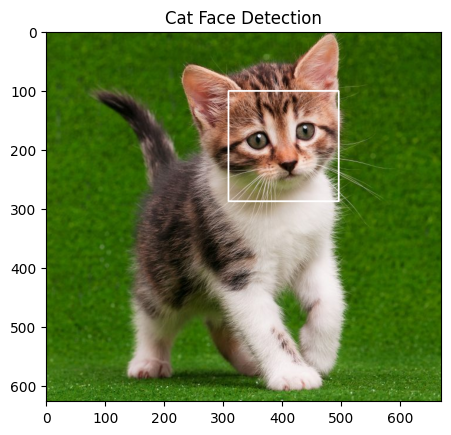

In [70]:
img_path_cat = '/content/drive/MyDrive/PCVK/Images/kitten01.jpg'
cat_cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalcatface_extended.xml'

img_color = cv.imread(img_path_cat)

if img_color is None:
    print(f"ERROR: Cat image file not found at path: {img_path_cat}")
elif not os.path.exists(cat_cascade_path):
    print(f"WARNING: Cat cascade file ('{cat_cascade_path}') NOT FOUND.")
else:
    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
    cat_cascade = cv.CascadeClassifier(cat_cascade_path)

    # Detect cat faces
    cat_faces = cat_cascade.detectMultiScale(img_gray, scaleFactor=1.05, minNeighbors=5)

    img_draw = img_color.copy()

    for (x, y, w, h) in cat_faces:
        # Draw white rectangle (BGR: 255, 255, 255)
        cv.rectangle(img_draw, (x, y), (x + w, y + h), (255, 255, 255), 2)

    # Display the result
    plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
    plt.title('Cat Face Detection')
    plt.show()

3.	Also try eye detection on Mr Prabowo's face:

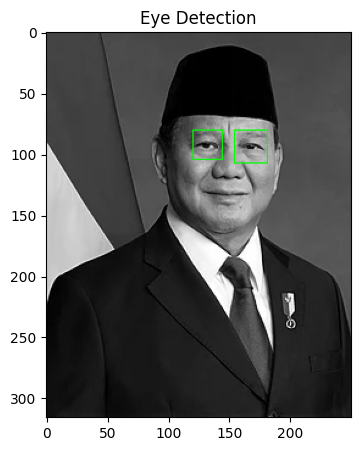

In [74]:
img_path_prabowo = '/content/drive/MyDrive/PCVK/Images/facedet/prabowo.jpg'
eye_cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_eye.xml'

# Read the image (Grayscale)
prabowo = cv.imread(img_path_prabowo, 0)

# Load the eye cascade classifier
eye_cascade = cv.CascadeClassifier(eye_cascade_path)

# Check if the cascade file loaded successfully
if eye_cascade.empty():
    print(f"ERROR: Unable to load cascade file from path: {eye_cascade_path}")
else:
    # Detect eyes
    eyes = eye_cascade.detectMultiScale(prabowo, scaleFactor=1.1, minNeighbors=5)

    # Draw bounding boxes around each detected eye
    img_draw_eyes = cv.cvtColor(prabowo, cv.COLOR_GRAY2BGR)  # Convert to BGR for colored rectangles

    for (ex, ey, ew, eh) in eyes:
        cv.rectangle(img_draw_eyes, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 1)  # Green rectangle

    # Display the result
    plt.figure(figsize=(5, 5))
    plt.imshow(img_draw_eyes)
    plt.title('Eye Detection')
    plt.show()


4. Perform smile detection on the people image:

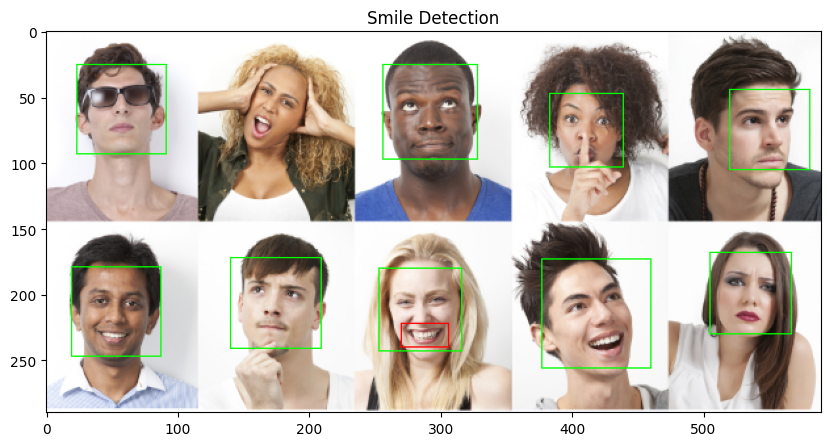

In [79]:
# Load cascades
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalface_alt.xml')
smile_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_smile.xml')

# Image path
people_path = '/content/drive/MyDrive/PCVK/Images/facedet/people.jpg'
img = cv.imread(people_path)

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

for (x, y, w, h) in faces:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 1)  # Face box
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = img[y:y + h, x:x + w]

    # Detect smiles with relaxed parameters
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (sx, sy, sw, sh) in smiles:
        cv.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 1)  # Smile box

# Display the result
plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Smile Detection")
plt.show()

5. Perform Face Tracking using Google Colab. Complete instructions and tutorials on camera access and Face Detection in Google Colab can be found at the following link: https://www.youtube.com/watch?v=YjWh7QvVH60

# Google Colab: Access Webcam for Images and Video
This notebook will go through how to access and run code on images and video taken using your webcam.  

For this purpose of this tutorial we will be using OpenCV's Haar Cascade to do face detection on our Webcam image and video.

In [80]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

## Helper Functions
Below are a few helper function to make converting between different image data types and formats.

In [81]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

## Haar Cascade Classifier
For this tutorial we will run a simple object detection algorithm called Haar Cascade on our images and video fetched from our webcam. OpenCV has a pre-trained Haar Cascade face detection model.

In [82]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

## Webcam Images
Running code on images taken from webcam is fairly straight-forward. We will utilize code within Google Colab's **Code Snippets** that has a variety of useful code functions to perform various tasks.

We will be using the code snippet for **Camera Capture** to utilize your computer's webcam.

In [87]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

In [94]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

## Webcam Videos
Running code on webcam video is a little more complex than images. We need to start a video stream using our webcam as input. Then we run each frame through our progam (face detection) and create an overlay image that contains bounding box of detection(s). We then overlay the bounding box image back onto the next frame of our video stream.

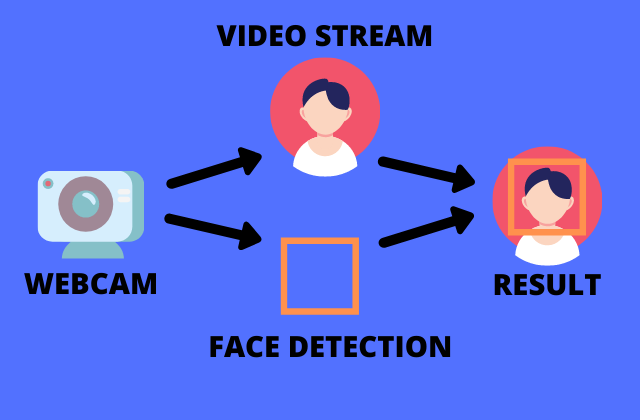</center>

In [95]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

In [97]:
# start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


6. Blur the detected face area. Here's an example of the output. Hint: You can use cv.medianBlur to blur.

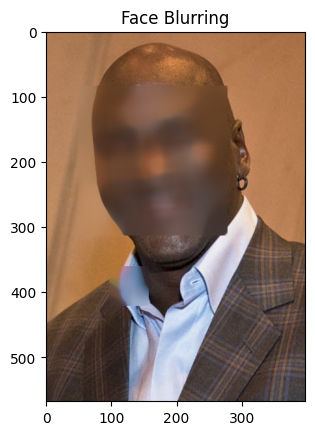

In [108]:
img_path_people = '/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg'
face_cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalface_default.xml'

face_cascade = cv.CascadeClassifier(face_cascade_path)

img_color = cv.imread(img_path_people)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# --- Face Detection ---
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.3, minNeighbors=5)

img_blurred = img_color.copy()

# --- Iterate and Apply Blurring ---
for (x, y, w, h) in faces:
    # Define the Region of Interest (ROI) for the detected face
    roi_face = img_blurred[y:y + h, x:x + w]

    # IMPORTANT: Apply blurring to the face ROI
    # cv.medianBlur requires an odd kernel size. A value of 41 gives a strong blur.
    blurred_face = cv.medianBlur(roi_face, 41)

    # Replace the face area in the main image with the blurred face
    img_blurred[y:y + h, x:x + w] = blurred_face

# Display the Result
plt.imshow(cv.cvtColor(img_blurred, cv.COLOR_BGR2RGB))
plt.title('Face Blurring')
plt.show()

7.	Processing each KTM image

  a. The following is an example of a KTM

  b. Display the KTM photo as in the following example:
  
  c. Perform KTM object detection on images containing KTMs and other items using the Feature Matching concept

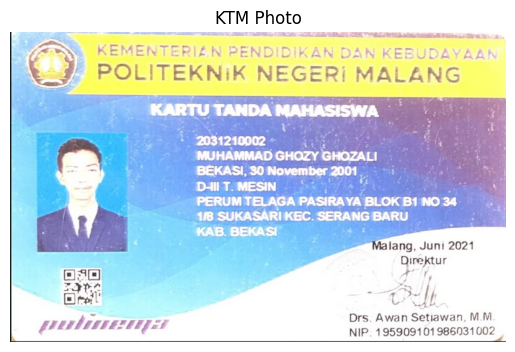

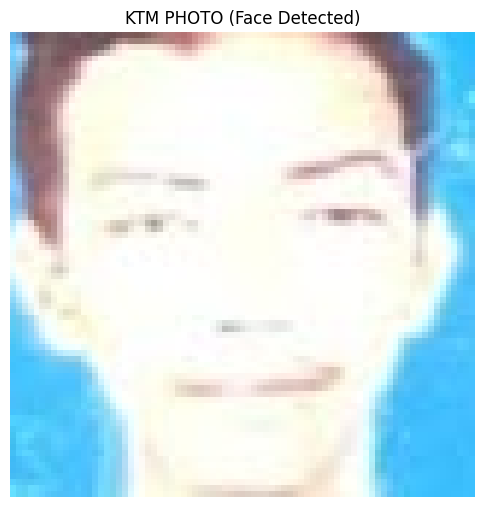

In [112]:
ktm_path = '/content/drive/MyDrive/PCVK/Images/KTM lama.jpg'
img_ktm = cv2.imread(ktm_path)

# Display the KTM photo
plt.imshow(cv2.cvtColor(img_ktm, cv2.COLOR_BGR2RGB))
plt.title("KTM Photo")
plt.axis('off')
plt.show()

# Convert to grayscale
gray = cv2.cvtColor(img_ktm, cv2.COLOR_BGR2GRAY)

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Take the first detected face (if more than one)
(x, y, w, h) = faces[0]

# Crop the face area
face_roi = img_ktm[y:y+h, x:x+w]

# Display the cropped result
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))
plt.title("KTM PHOTO (Face Detected)")
plt.axis('off')
plt.show()

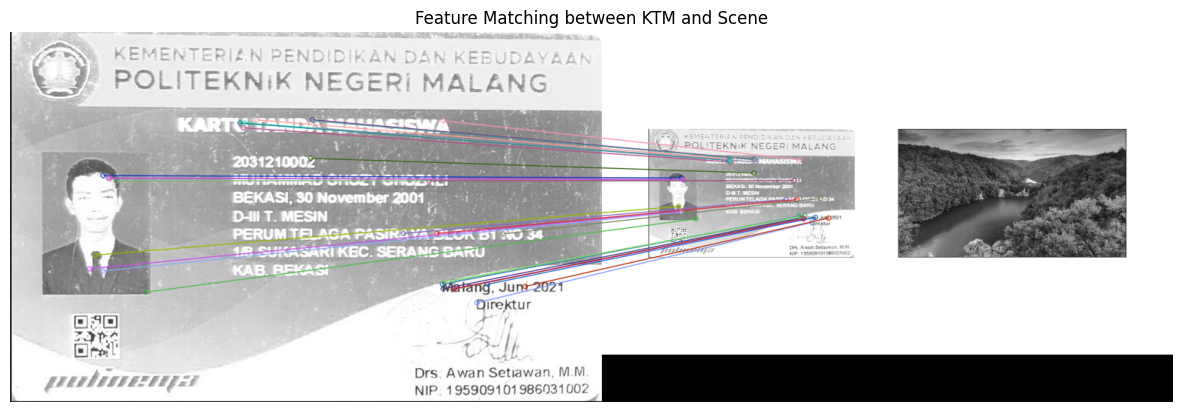

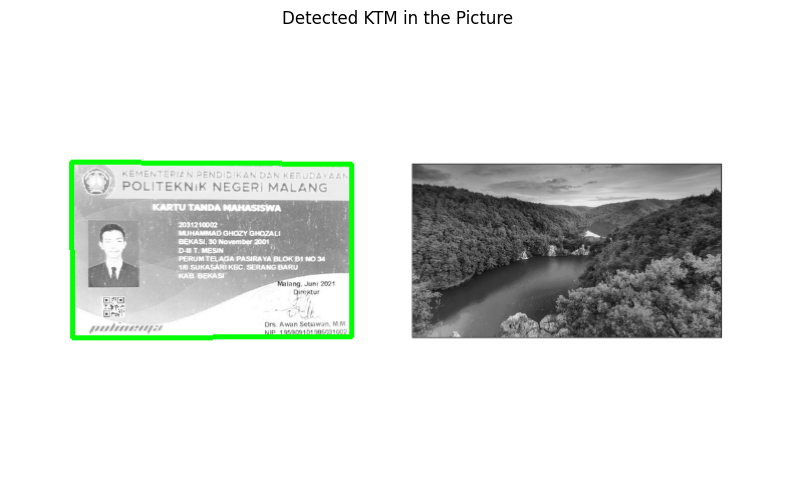

In [133]:
# --- Load Images ---
img_object = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg', cv.IMREAD_GRAYSCALE)
img_scene = cv.imread('/content/drive/MyDrive/PCVK/Images/feature matching.png', cv.IMREAD_GRAYSCALE)

# --- Initialize ORB (Oriented FAST and Rotated BRIEF) ---
orb = cv.ORB_create(nfeatures=1000)

# --- Detect keypoints and descriptors ---
kp1, des1 = orb.detectAndCompute(img_object, None)
kp2, des2 = orb.detectAndCompute(img_scene, None)

# --- Feature matching using Brute-Force Matcher ---
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# --- Visualize the feature matching result ---
result_img = cv.drawMatches(img_object, kp1, img_scene, kp2, matches[:30], None, flags=2)

plt.figure(figsize=(15, 7))
plt.imshow(result_img, cmap='gray')
plt.title("Feature Matching between KTM and Scene")
plt.axis('off')
plt.show()

# --- Estimate the location of the KTM in the scene ---
if len(matches) > 10:
    # Get the matched keypoint coordinates
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute homography (to find the object location in the scene)
    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

    if M is not None:
        h, w = img_object.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(pts, M)

        img_scene_color = cv.cvtColor(img_scene, cv.COLOR_GRAY2BGR)
        cv.polylines(img_scene_color, [np.int32(dst)], True, (0, 255, 0), 3)

        plt.figure(figsize=(10, 8))
        plt.imshow(cv.cvtColor(img_scene_color, cv.COLOR_BGR2RGB))
        plt.title("Detected KTM in the Picture")
        plt.axis('off')
        plt.show()
    else:
        print("⚠️ Homography not found. Try different images.")
else:
    print("⚠️ Not enough matches found.")

## Additional Practical Assignment:
Display the characters on this KTM using Deep Learning to perform character recognition. Before training data, first prepare the data to be trained: image data of numbers 0-9.
To create this data, you can use an image editor to crop one person. Then, use the source code below to prepare for the training.

The explanation of the code above is as follows:

i. First, import the required packages.
Some new packages include tqdm, which is used to load data followed by a progress bar. numpy is a package used to perform matrix or array operations. Pickle is a dependency for storing files for the training data model.

ii. Loop over the training data, which will later be used to label the recognition results. Loop over all training files to convert them into an image array.

iii. The X and Y variables are used to store labels and features. Labels contain the characters A-Z and 0-9, while features contain the image array data for each label.

iv. Finally, write the contents of the X and Y variables to a pickle file. This pickle file will be loaded during the training data process.

In [145]:
import os
import cv2
import random
import numpy as np
import pickle
from tqdm import tqdm

# --- Dataset Path ---
DATADIR = "/content/drive/MyDrive/PCVK/Dataset/Training"
width, height = 100, 100

training_data = []

# --- Loop through each class folder ---
for class_name in sorted(os.listdir(DATADIR)):
    class_path = os.path.join(DATADIR, class_name)
    if not os.path.isdir(class_path):
        continue

    class_num = sorted(os.listdir(DATADIR)).index(class_name)
    print(f"Processing {class_num}: {class_name}")

    for img_name in tqdm(os.listdir(class_path)):
        try:
            img_path = os.path.join(class_path, img_name)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (width, height))
            training_data.append([new_array, class_num])
        except Exception as e:
            pass

# --- Shuffle and Split Features + Labels ---
random.shuffle(training_data)

X = []
Y = []

for feature, label in training_data:
    X.append(feature)
    Y.append(label)

X = np.array(X).reshape(-1, width, height, 1)
Y = np.array(Y)

# --- Check shapes ---
print("\nX shape:", X.shape)
print("Y shape:", Y.shape)
print("Same length:", len(X) == len(Y))

# --- Save as pickle ---
with open("X.pickle", "wb") as f:
    pickle.dump(X, f)
with open("Y.pickle", "wb") as f:
    pickle.dump(Y, f)

print("Dataset saved to X.pickle and Y.pickle.")


Processing 0: 0


100%|██████████| 20/20 [00:00<00:00, 195.85it/s]


Processing 1: 1


100%|██████████| 20/20 [00:00<00:00, 172.01it/s]


Processing 2: 2


...

Processing 8: 8


100%|██████████| 20/20 [00:00<00:00, 20.62it/s]


Processing 9: 9


100%|██████████| 20/20 [00:00<00:00, 124.77it/s]


X shape: (200, 100, 100, 1)
Y shape: (200,)
Same length: True
Dataset saved to X.pickle and Y.pickle.


Training Data

In [149]:
import pickle
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.utils import to_categorical

# --- Load Pickled Dataset ---
with open("X.pickle", "rb") as f:
    X = pickle.load(f)

with open("Y.pickle", "rb") as f:
    Y = pickle.load(f)

# --- Normalize & One-Hot Encode ---
X = X / 255.0
Y = to_categorical(Y)

width, height = 100, 100

# --- Build CNN Model ---
inputs = Input(shape=(width, height, 1))
conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
conv_layer = Conv2D(16, (5, 5), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(32, (3, 3), activation='relu')(conv_layer)
conv_layer = Conv2D(32, (3, 3), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(64, (3, 3), activation='relu')(conv_layer)

flaten = Flatten()(conv_layer)
fc_layer = Dense(256, activation='relu')(flaten)
fc_layer = Dense(64, activation='relu')(fc_layer)

# Output layer (10 classes, since you have 0–9)
outputs = Dense(10, activation='softmax')(fc_layer)

# --- Compile Model ---
adam = Adam(learning_rate=0.0001)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# --- Train Model ---
model.fit(X, Y, epochs=20, verbose=1)

# --- Save Model ---
model.save('anpr.keras')
print("Model training complete and saved as 'anpr.keras'")


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 448ms/step - accuracy: 0.0579 - loss: 2.3153
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - accuracy: 0.1193 - loss: 2.3034
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 610ms/step - accuracy: 0.0850 - loss: 2.3004
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 461ms/step - accuracy: 0.1712 - loss: 2.2958
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 410ms/step - accuracy: 0.1208 - loss: 2.2904
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.2678 - loss: 2.2809
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 641ms/step - accuracy: 0.3841 - loss: 2.2655
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 0.5547 - loss: 2.2480
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.4494 - loss: 2.2105
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 634ms/step - accuracy: 0.4780 - loss: 2.1686
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 436ms/step - accuracy: 0.4727 - loss: 2.0788
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.5246 - lo

Testing Data

In [154]:
import os
import cv2
import numpy as np
import tensorflow as tf

# --- Path dataset ---
data_dir_training = "/content/drive/MyDrive/PCVK/Dataset/Training"
data_dir_testing = "/content/drive/MyDrive/PCVK/Dataset/Testing"

# --- Parameter ---
width, height = 100, 100

# --- Load model yang sudah dilatih ---
model = tf.keras.models.load_model("anpr.keras")

# --- Ambil nama-nama kelas dari folder training ---
dirs = sorted(os.listdir(data_dir_training))

# --- Loop untuk setiap folder kendaraan di dataset testing ---
for car_folder in sorted(os.listdir(data_dir_testing)):
    car_path = os.path.join(data_dir_testing, car_folder)
    if not os.path.isdir(car_path):
        continue

    temp = ""  # untuk menyimpan hasil prediksi karakter

    # --- Loop setiap gambar karakter di folder kendaraan ---
    for char_img in sorted(os.listdir(car_path)):
        img_path = os.path.join(car_path, char_img)
        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue

        # Preprocessing gambar
        new_array = cv2.resize(img_array, (width, height))
        new_array = np.array(new_array).reshape(-1, width, height, 1)
        new_array = new_array / 255.0  # normalisasi

        # Prediksi karakter
        prediction = model.predict(new_array)
        predicted_label = dirs[np.argmax(prediction[0])]
        temp += predicted_label  # gabungkan hasil prediksi

    # --- Tampilkan hasil prediksi ---
    print(f"Folder name: {car_folder}  →  Predicted number: {temp}")